# Total Features + RFECV + LightGBM: MLOps Research Notebook

Notebook này chạy và kiểm định cùng process của `research_total_features_rfecv_lgbm.py`. Mỗi pha có metadata, bảng kiểm tra, biểu đồ và artifact có thể truy vết.

**Các pha:** data contract -> feature profiling -> RFECV -> final model -> threshold -> validation/test diagnostics -> quality gates -> MLflow/artifact audit.

Các cell chạy nghiên cứu mặc định tắt để tránh huấn luyện ngoài ý muốn.

In [1]:
from __future__ import annotations

import json
import os
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT = Path(r"D:\SCJ999\srateries\RandomForest\RF_MLFlow")
CACHE_FAMILY = "initial_non_bb_candidates"
SCRIPT = PROJECT / "research_total_features_rfecv_lgbm.py"
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "axes.titleweight": "bold"})
print({"project": str(PROJECT), "python": sys.version.split()[0], "platform": platform.platform()})

{'project': 'D:\\SCJ999\\srateries\\RandomForest\\RF_MLFlow', 'python': '3.11.9', 'platform': 'Windows-10-10.0.26200-SP0'}


## 1. Experiment parameters and reproducibility

In [2]:
# Safe defaults: inspect and smoke test are opt-in.
RUN_REBUILD_CACHE = False
RUN_SMOKE = False
RUN_RESEARCH = False
ENABLE_MLFLOW = True
SAVE_PREDICTIONS = False
LOG_DIAGNOSTICS = True

SEED = 860906
research_config = dict(
    run_id=int(time.time()),
    cache_family=CACHE_FAMILY,
    force_cache=False,
    max_train_rows=120000,
    rfecv_rows=50000,
    min_features_to_select=60,
    rfecv_step=50,
    cv_splits=3,
    seed=SEED,
    n_estimators_rfecv=250,
    n_estimators_final=1200,
    n_jobs=4,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    protect_time_features=True,
    protect_passthrough=False,
    enable_mlflow=ENABLE_MLFLOW,
    save_predictions=SAVE_PREDICTIONS,
    log_diagnostics=LOG_DIAGNOSTICS,
    shap_rows=0,
)
pd.Series(research_config, name="value")

run_id                                   1788881081
cache_family              initial_non_bb_candidates
force_cache                                   False
max_train_rows                               120000
rfecv_rows                                    50000
min_features_to_select                           60
rfecv_step                                       50
cv_splits                                         3
seed                                         860906
n_estimators_rfecv                              250
n_estimators_final                             1200
n_jobs                                            4
learning_rate                                  0.03
num_leaves                                       31
max_depth                                        -1
protect_time_features                          True
protect_passthrough                           False
enable_mlflow                                  True
save_predictions                              False
log_diagnost

## 2. Environment and data contract
Kiểm tra dependency, cache manifest, schema và tỷ lệ label trước khi tốn tài nguyên cho RFECV.

In [3]:
import lightgbm as lgb
import sklearn
from config import CFG
from research_random50_initial_features import META_COLS, build_cache
from research_total_features_rfecv_lgbm import run as run_total_rfecv_lgbm

cols_path = PROJECT / "cache" / CACHE_FAMILY / "feature_columns.json"
assert SCRIPT.exists(), SCRIPT
assert cols_path.exists(), cols_path
cols = json.loads(cols_path.read_text(encoding="utf-8"))
versions = {"lightgbm": lgb.__version__, "sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__}
contract = {
    "cache_family": CACHE_FAMILY,
    "feature_columns": len(cols),
    "duplicate_features": int(pd.Series(cols).duplicated().sum()),
    "train_years": list(CFG.split.train_years),
    "valid_years": list(CFG.split.valid_years),
    "test_years": list(CFG.split.test_years),
    "scaling": "rolling_zscore",
    "label_column": "label",
}
display(pd.DataFrame([versions, contract]).T.rename(columns={0: "value", 1: "contract"}))
assert contract["duplicate_features"] == 0
assert contract["feature_columns"] > 0

,value,contract
lightgbm,4.6.0,NaN
sklearn,1.5.2,NaN
pandas,2.3.1,NaN
numpy,1.26.4,NaN
cache_family,NaN,initial_non_bb_candidates
feature_columns,NaN,1404.0
duplicate_features,NaN,0.0
train_years,NaN,"[2018, 2019, 2020, 2021, 2022]"
valid_years,NaN,[2023]
test_years,NaN,"[2024, 2025, 2026]"


In [9]:
sample_path = PROJECT / "cache" / CACHE_FAMILY / "candidates_2018.parquet"
sample = pd.read_parquet(sample_path)
sample_features = [c for c in sample.columns if c not in META_COLS and c != "label"]
data_quality = pd.DataFrame({
    "metric": ["rows", "columns", "features", "missing_cells", "infinite_cells", "label_rate", "year_min", "year_max"],
    "value": [len(sample), len(sample.columns), len(sample_features), int(sample.isna().sum().sum()), int(np.isinf(sample.select_dtypes(include=np.number)).sum().sum()), float(sample["label"].mean()), int(sample["year"].min()), int(sample["year"].max())],
})
display(data_quality)
assert data_quality.loc[data_quality.metric == "missing_cells", "value"].item() == 0
assert data_quality.loc[data_quality.metric == "infinite_cells", "value"].item() == 0

,metric,value
0,rows,112082.000000
1,columns,1410.000000
2,features,1404.000000
3,missing_cells,0.000000
4,infinite_cells,0.000000
5,label_rate,0.472172
6,year_min,2018.000000
7,year_max,2018.000000


### Data profiling charts

Index(['feature'], dtype='object')


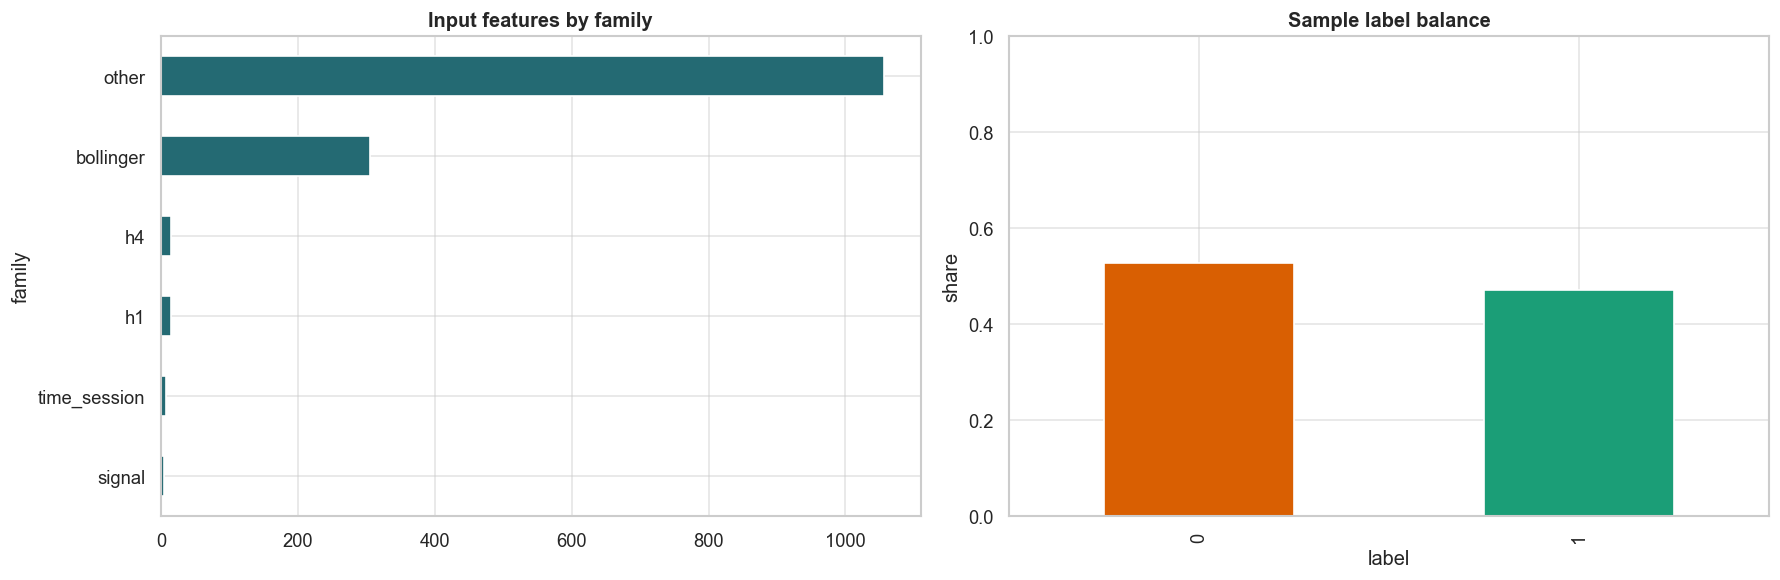

In [10]:
feature_df = pd.DataFrame({"feature": cols})
print(feature_df.columns)
feature_df["family"] = np.select(
    [#feature_df.feature.str.contains("_ov_", regex=False),
     feature_df.feature.str.startswith("bb"),
     #feature_df.feature.str.startswith(("keltner", "donchian")),
     #feature_df.feature.str.startswith("vwap"),
     #feature_df.feature.str.startswith(("ichimoku", "parabolic_sar", "supertrend")),
     feature_df.feature.str.startswith("h4_"),
     feature_df.feature.str.startswith("h1_"),
     #feature_df.feature.str.startswith("m15_"),
     #feature_df.feature.str.startswith("m5_"),
     feature_df.feature.str.startswith(("tod_", "dow_", "session_")),
     feature_df.feature.str.startswith("sig_") |
     (feature_df.feature == "buy_signal")
     ],
    [#"overlay",
     "bollinger",
     #"channel",
     #"vwap",
     #"trendline",
     "h4",
     "h1",
     #"m15",
     #"m5",
     "time_session",
     "signal"],
    default="other",
)
family_counts = feature_df.family.value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
family_counts.plot.barh(ax=axes[0], color="#246a73", title="Input features by family")
sample["label"].value_counts(normalize=True).sort_index().plot.bar(ax=axes[1], color=["#d95f02", "#1b9e77"], title="Sample label balance")
axes[1].set_xlabel("label"); axes[1].set_ylabel("share"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 3. Optional cache rebuild and smoke test
Smoke test chỉ kiểm tra control flow; không dùng để kết luận chất lượng model.

In [12]:
if RUN_REBUILD_CACHE:
    build_cache(True)

smoke_config = {**research_config, "run_id": int(time.time()), "max_train_rows": 3000, "rfecv_rows": 1500, "min_features_to_select": 20, "rfecv_step": 300, "cv_splits": 2, "n_estimators_rfecv": 20, "n_estimators_final": 40, "n_jobs": 2, "enable_mlflow": False, "shap_rows": 0}
if RUN_SMOKE:
    smoke_summary = run_total_rfecv_lgbm(**smoke_config)
    display(pd.Series(smoke_summary, name="smoke"))



IndentationError: unindent does not match any outer indentation level (<tokenize>, line 9)

## 4. RFECV and final training
RFECV chỉ fit trên train years; validation/test được giữ ngoài quá trình chọn feature.

In [ ]:
if RUN_RESEARCH:
    research_config["run_id"] = int(time.time())

    summary = run_total_rfecv_lgbm(**research_config)
    RESULT_RUN_ID = research_config["run_id"]
else:
    RESULT_RUN_ID = research_config["run_id"]
RESULT_DIR = PROJECT / "outputs" / f"total_features_rfecv_lgbm_{RESULT_RUN_ID}"
print("RESULT_DIR:", RESULT_DIR)

## 5. RFECV evidence and feature-selection charts

In [ ]:
rank_path = RESULT_DIR / "rfecv_feature_ranking.csv"
cv_path = RESULT_DIR / "rfecv_cv_results.csv"
if rank_path.exists():
    ranking = pd.read_csv(rank_path)
    selected_count = int(ranking.selected.sum())
    display(ranking.head(30))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ranking.ranking.value_counts().sort_index().plot.bar(ax=axes[0], color="#5b8e7d", title="RFECV rank distribution")
    ranking.groupby("selected").size().rename({False: "dropped", True: "selected"}).plot.bar(ax=axes[1], color=["#d95f02", "#1b9e77"], title="Selected vs dropped")
    axes[1].set_ylabel("features"); plt.tight_layout(); plt.show()
if cv_path.exists():
    cv_results = pd.read_csv(cv_path)
    score_col = next((c for c in ["mean_test_score", "mean_score_time"] if c in cv_results), None)
    if score_col == "mean_test_score":
        plt.figure(figsize=(10, 5)); plt.plot(cv_results["n_features"], cv_results[score_col], marker="o", color="#264653")
        plt.xlabel("number of features"); plt.ylabel("mean time-series ROC-AUC"); plt.title("RFECV cross-validation curve"); plt.tight_layout(); plt.show()

## 6. Model explainability and threshold selection

In [ ]:
imp_path = RESULT_DIR / "model" / "lgbm_feature_importance.csv"
valid_curve_path = RESULT_DIR / "model" / "threshold_valid.csv"
test_curve_path = RESULT_DIR / "model" / "threshold_test.csv"
if imp_path.exists():
    importance = pd.read_csv(imp_path).sort_values("importance", ascending=False)
    importance["family"] = importance.feature.map(feature_df.set_index("feature").family).fillna("selected")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    importance.head(25).sort_values("importance").plot.barh(x="feature", y="importance", ax=axes[0], legend=False, color="#e76f51", title="Top 25 LightGBM features")
    importance.groupby("family").importance.sum().sort_values().plot.barh(ax=axes[1], color="#2a9d8f", title="Importance mass by family")
    plt.tight_layout(); plt.show()
if valid_curve_path.exists() and test_curve_path.exists():
    valid_curve = pd.read_csv(valid_curve_path); test_curve = pd.read_csv(test_curve_path)
    metric = "winrate" if "winrate" in valid_curve else "precision"
    plt.figure(figsize=(11, 5))
    plt.plot(valid_curve["threshold"], valid_curve[metric], marker="o", label=f"valid {metric}")
    plt.plot(test_curve["threshold"], test_curve[metric], marker="o", label=f"test {metric}")
    plt.xlabel("probability threshold"); plt.ylabel(metric); plt.title("Threshold stability: validation vs test"); plt.legend(); plt.tight_layout(); plt.show()
    display(test_curve.sort_values(metric, ascending=False).head(10))

## 7. Validation/test diagnostics
Các chart ROC, PR, calibration, probability distribution, confusion matrix, yearly và monthly đã được tạo bởi pipeline khi `LOG_DIAGNOSTICS=True`. Notebook hiển thị lại để review tập trung.

In [ ]:
from IPython.display import Image
chart_names = [
    "total_features_rfecv_lgbm_roc_valid.png", "total_features_rfecv_lgbm_roc_test.png",
    "total_features_rfecv_lgbm_pr_valid.png", "total_features_rfecv_lgbm_pr_test.png",
    "total_features_rfecv_lgbm_calibration_valid.png", "total_features_rfecv_lgbm_calibration_test.png",
    "total_features_rfecv_lgbm_prob_distribution_valid_test.png",
    "total_features_rfecv_lgbm_confusion_test.png",
    "total_features_rfecv_lgbm_yearly_test_selected_threshold.png",
    "total_features_rfecv_lgbm_monthly_test_selected_threshold.png",
]
available_charts = [RESULT_DIR / "model" / name for name in chart_names if (RESULT_DIR / "model" / name).exists()]
for chart in available_charts:
    print(chart.name)
    display(Image(filename=str(chart)))

In [ ]:
metrics_path = RESULT_DIR / "metrics.json"
summary_path = RESULT_DIR / "summary.json"
if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    metrics_df = pd.json_normalize(metrics, sep=".").T.rename(columns={0: "value"})
    display(metrics_df)
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    display(pd.Series(summary, name="summary"))

## 8. MLOps quality gates and artifact audit
Quality gates biến kết quả nghiên cứu thành tín hiệu có thể dùng trong CI/review. Ngưỡng dưới đây là mặc định conservative và có thể điều chỉnh theo mục tiêu giao dịch.

In [ ]:
QUALITY_GATES = {"min_valid_auc": 0.50, "min_test_auc": 0.50, "min_selected_features": 1, "require_bundle": True}
gate_rows = []
if summary_path.exists():
    evaluated_summary = json.loads(summary_path.read_text(encoding="utf-8"))
    gate_rows.extend([
        {"gate": "valid_auc", "actual": evaluated_summary.get("valid_auc"), "minimum": QUALITY_GATES["min_valid_auc"]},
        {"gate": "test_auc", "actual": evaluated_summary.get("test_auc"), "minimum": QUALITY_GATES["min_test_auc"]},
        {"gate": "selected_features", "actual": evaluated_summary.get("selected_features"), "minimum": QUALITY_GATES["min_selected_features"]},
    ])
bundle_path = RESULT_DIR / "model" / "total_features_rfecv_lgbm_bundle.joblib"
gate_rows.append({"gate": "model_bundle", "actual": int(bundle_path.exists()), "minimum": int(QUALITY_GATES["require_bundle"])})
gates = pd.DataFrame(gate_rows)
if not gates.empty:
    gates["passed"] = gates.actual >= gates.minimum
    display(gates)
    assert bool(gates.passed.all()), "MLOps quality gate failed"

artifact_manifest = []
if RESULT_DIR.exists():
    for path in sorted(RESULT_DIR.rglob("*")):
        if path.is_file():
            artifact_manifest.append({"path": str(path.relative_to(RESULT_DIR)), "bytes": path.stat().st_size, "suffix": path.suffix})
manifest_df = pd.DataFrame(artifact_manifest)
display(manifest_df)

## 9. Reproducibility record
Lưu config, môi trường, đường dẫn kết quả và trạng thái quality gate để review hoặc tái chạy.

In [ ]:
run_record = {
    "created_at_utc": pd.Timestamp.utcnow().isoformat(),
    "project": str(PROJECT),
    "script": str(SCRIPT),
    "result_dir": str(RESULT_DIR),
    "config": research_config,
    "versions": versions,
    "contract": contract,
    "quality_gates": QUALITY_GATES,
    "gate_passed": bool(gates.passed.all()) if not gates.empty else False,
    "artifact_count": len(manifest_df),
}
display(pd.Series(run_record, name="run_record"))
record_path = RESULT_DIR / "notebook_mlops_run_record.json"
if RESULT_DIR.exists():
    record_path.write_text(json.dumps(run_record, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    print("saved:", record_path)